# Проект. Исследование данных и создание метрик
#  «Анализ данных о поездках на такси в Перу»

## Шаг 1


**Описание данных:**

passengers:
- journey_id – уникальный id поездки  
- user_id – id пользователя  
- start_type – тип заказа (asap, reserved, delayed)  
- start_lat – исходное местоположение пользователя, широта  
- start_lon – исходное местоположение пользователя, долгота  
- source – платформа, с которой сделан заказ  
- driver_score – какую оценку клиент поставил водителю  

drivers:
- journey_id – уникальный id поездки  
- driver_id – id водителя  
- taxi_id – id машины  
- icon – тип поездки  
- start_at – время начала поездки  
- end_at – время окончания поездки  
- end_lat – итоговое местоположение, широта  
- end_lon – итоговое местоположение, долгота  
- end_state – состояние заказа  
- driver_start_lat – исходное местоположение водителя, широта  
- driver_start_lon – исходное местоположение водителя, долгота  
- arrived_at – время прибытия водителя  
- rider_score – какую оценку водитель поставил клиенту  

## Шаг 2

**Собрала первую часть данных.** Для этого прочитайте датасеты `passengers` и `drivers`. Объединила датафреймы в единый по ключу — колонке `journey_id`.

In [4]:
import pandas as pd

In [11]:
passengers = pd.read_csv ('/mnt/HC_Volume_18315164/home-jupyter/jupyter-ekaterina--cky8935/passengers.csv', encoding='Windows-1251' )
drivers = pd.read_csv ('/mnt/HC_Volume_18315164/home-jupyter/jupyter-ekaterina--cky8935/drivers.csv', encoding='Windows-1251')

In [12]:
drivers.shape

(11555, 13)

In [13]:
pass_drive = passengers.merge(drivers, on='journey_id', how='inner')

In [24]:
pass_drive.shape

(11555, 19)

In [25]:
pass_drive.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11555 entries, 0 to 11554
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   journey_id        11555 non-null  object 
 1   user_id           11555 non-null  object 
 2   start_type        11555 non-null  object 
 3   start_lat         11555 non-null  object 
 4   start_lon         11555 non-null  object 
 5   source            11500 non-null  object 
 6   driver_score      3151 non-null   float64
 7   driver_id         8170 non-null   object 
 8   taxi_id           8170 non-null   object 
 9   icon              11555 non-null  object 
 10  start_at          11555 non-null  object 
 11  end_at            11284 non-null  object 
 12  end_lat           11555 non-null  object 
 13  end_lon           11555 non-null  object 
 14  end_state         11543 non-null  object 
 15  driver_start_lat  8164 non-null   object 
 16  driver_start_lon  8164 non-null   object

## Шаг 3

**Первую часть данных (объединенный датафрейм) соединила со второй частью из датасета `taxi_2`.**

In [14]:
taxi_2 = pd.read_csv ('/mnt/HC_Volume_18315164/home-jupyter/jupyter-ekaterina--cky8935/taxi_2.csv', encoding='Windows-1251' )
taxi_2

,journey_id,user_id,driver_id,taxi_id,icon,start_type,start_at,start_lat,start_lon,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,source,driver_score,rider_score
0,b6206048fbda6d454ead4fa2b4b9beaf,d0de230345480ca6bcc86ce1eb89fbfa,40187316352d2c03ddc19e9c8ad7c514,42aa958edf790ef3d45823386fb734ea,executive,asap,2010-11-30 03:38:00,"-11,95227432","-76,81442261",2010-11-30 03:39:00,"40,4052887","-3,72117424",rider cancel,"-12,08863069","-76,96650439",NaN,iPhone,NaN,NaN
1,d2cf43d9f47c6512b84e1ea7b8746a0c,8e37a68fab5f31a5e2c1b5f77c6bb9e5,1d8ba0bdacccf2d0d70ee9925185d231,1d8ba0bdacccf2d0d70ee99251862c54,executive,reserved,2010-11-28 22:30:00,"-12,0495456","-77,1116799",2010-11-29 00:22:00,"-12,11973","-76,998734",drop off,"-12,04809647","-77,096405",2010-11-28 22:02:00,web,NaN,NaN
2,7c01cd25b39f4f8b234bf56d48a5e9c9,8e37a68fab5f31a5e2c1b5f77c6bb9e5,ecdcce0c956e266ed26c80fd9e5cbb8f,1d3c551d7fc3d0daf73f0a8c82781c2d,executive,reserved,2010-11-28 22:30:00,"-12,0511575","-77,1300437",2010-11-28 23:04:00,"-12,0794453","-77,0896372",drop off,0,0,2010-11-28 22:34:00,web,NaN,NaN
3,ab90a1bf4289d96e78d4a47d7cc2286d,1e639fc120efea2675ac138ebeac4c2f,12c472dd8efc6ed622ae8669251b82f1,c26f22be31323781fd478dbcf8926d44,executive,asap,2010-11-28 01:04:00,"-12,0979889","-77,0223812",2010-11-28 01:32:00,"-12,1192177","-77,0413569",drop off,"-12,08757569","-77,03611258",2010-11-28 01:15:00,web,NaN,4.0
4,d2cf43d9f47c6512b84e1ea7b8740874,2f1882c87731970df63e69d4bc254f96,3abce16ea601affbeae8f50584ce72ef,ab6ee368af1a9e1293acc0d14d1f9338,executive,reserved,2010-11-28 01:50:00,"-12,0903136","-77,0424105",2010-11-28 02:18:00,"43,5398067","-5,6575304",drop off,"-12,11418993","-77,03732522",2010-11-28 01:43:00,Wap,NaN,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11551,4a18ea5737ce0ffecaf20b305a0e2c86,8998bb370b5f0cec43a373adebba0c72,d665fb9f75ef5d9cd0fd89479380ba78,16cbe35db7fff70fbc8251b4cda9fdc9,executive,reserved,2010-07-31 13:15:00,"-12,08974075","-77,04699707",2010-07-31 13:27:00,"-12,08352661","-77,05044556",drop off,"-12,08973527","-77,04787016",2010-07-31 13:15:00,iPhone,5.0,5.0
11552,f1e4317f2c17991dd90d1cd17ae0d399,5f8a6ffef0ea5df78a8ee890267b60ec,17c21284245ff240c7212732991c2373,716a697375634f32a06d692b0448f13d,executive,asap,2010-10-02 05:26:00,"-12,09253011","-77,02875271",2010-10-02 05:56:00,"-12,07776001","-77,05623798",drop off,"-12,10639693","-77,04028948",2010-10-02 05:39:00,Android,NaN,5.0
11553,1e44c0fd0a266c3719ff30410b257bce,c0ffb6f6cd801004dd8609c12277c2d1,4851ee4c867c9b49b909c1adb76c31e9,4851ee4c867c9b49b909c1adb76c538e,executive,asap,2010-09-21 09:56:00,"-12,1275637","-77,02642288",2010-09-21 10:18:00,"-12,10529838","-77,04735249",drop off,"-12,12605017","-77,01882491",2010-09-21 10:05:00,Android,0.0,0.0
11554,7073883383b89ad289e864022150cdd7,c0ffb6f6cd801004dd8609c12277c2d1,56f59b58bcbbd1cdabc3652e713134c2,924d4f0e7554566623e8ebb3904a7b0c,executive,reserved,2010-04-29 04:30:00,"-12,019468","-77,1077669",2010-04-29 05:11:00,"-12,09909987","-77,03475013",drop off,"-12,0710933","-77,09855131",2010-04-29 04:23:00,Android,NaN,5.0


In [28]:
taxi_2.shape

(11556, 19)

In [15]:
full_taxi = pd.concat([taxi_2,pass_drive])

In [32]:
full_taxi.shape

(23111, 19)

## Шаг 4

Узнала есть ли в данных пропущенные значения и как много.

In [33]:
full_taxi.isna().sum()

journey_id              0
user_id                 0
driver_id            3385
taxi_id              3385
icon                    0
start_type              0
start_at                0
start_lat               0
start_lon               0
end_at                276
end_lat                 0
end_lon                 0
end_state              12
driver_start_lat     3490
driver_start_lon     3490
arrived_at           5395
source                123
driver_score        15461
rider_score          7721
dtype: int64

## Шаг 5

Провела анализ данных платформ.

In [34]:
full_taxi.source.unique()

array(['iPhone', 'web', 'Wap', 'Android', 'iPad', nan], dtype=object)

In [35]:
full_taxi.source.nunique()

5

## Шаг 6

**Определила долю заказов, сделанных с той или иной платформы.**

In [40]:
full_taxi.source.value_counts(normalize= True)

iPhone     0.423743
web        0.331956
Android    0.213546
iPad       0.024839
Wap        0.005916
Name: source, dtype: float64

In [41]:
full_taxi.source.value_counts(normalize= True)*100

iPhone     42.374282
web        33.195580
Android    21.354620
iPad        2.483905
Wap         0.591613
Name: source, dtype: float64

In [19]:
(full_taxi.source.value_counts(normalize= True)*100). round ()

iPhone     42.0
web        33.0
Android    21.0
iPad        2.0
Wap         1.0
Name: source, dtype: float64

## Шаг 7

Построила график.

In [20]:
full_taxi.source.value_counts()

iPhone     9741
web        7631
Android    4909
iPad        571
Wap         136
Name: source, dtype: int64

In [21]:
full_taxi.source.value_counts().reset_index()

,index,source
0,iPhone,9741
1,web,7631
2,Android,4909
3,iPad,571
4,Wap,136


In [25]:
platform_count = full_taxi.Count.value_counts().reset_index().rename(columns={'index' : 'Platform', 'source' : 'Count'})
platform_count

AttributeError: 'DataFrame' object has no attribute 'Count'

In [23]:
import seaborn as sns

In [24]:
platform_count = full_taxi.Count.value_counts().reset_index().rename(columns={'index' : 'Platform', 'source' : 'Count'})
sns.barplot(data = platform_count, x = "Platform", y = "Count")

AttributeError: 'DataFrame' object has no attribute 'Count'

In [26]:
import matplotlib.pyplot as plt

## Шаг 8

Более детально проанализиривала распределение заказов по платформам.

In [27]:
sns.countplot(data = full_taxi, x = "Platform", y = "Count")

ValueError: Cannot pass values for both `x` and `y`

## Шаг 9

**Проверила, как распределены оценки водителей.**

In [45]:
full_taxi.driver_score.value_counts(normalize = True)

5.0    0.588105
4.0    0.218824
0.0    0.143007
3.0    0.029673
1.0    0.012288
2.0    0.008105
Name: driver_score, dtype: float64

In [46]:
(full_taxi.driver_score.value_counts(normalize = True)*100). round (2)

5.0    58.81
4.0    21.88
0.0    14.30
3.0     2.97
1.0     1.23
2.0     0.81
Name: driver_score, dtype: float64

In [58]:
driver_score_counts = (full_taxi.driver_score.value_counts(normalize = True).mul(100)). round (2).reset_index()
driver_score_counts

,index,driver_score
0,5.0,58.81
1,4.0,21.88
2,0.0,14.30
3,3.0,2.97
4,1.0,1.23
5,2.0,0.81


In [59]:
driver_score_counts = driver_score_counts.rename (columns = {'driver_score' : 'percentage', 'index' : 'driver_score'})
driver_score_counts


,driver_score,percentage
0,5.0,58.81
1,4.0,21.88
2,0.0,14.30
3,3.0,2.97
4,1.0,1.23
5,2.0,0.81


In [60]:
driver_score_counts.sort_values('driver_score')

,driver_score,percentage
2,0.0,14.30
4,1.0,1.23
5,2.0,0.81
3,3.0,2.97
1,4.0,21.88
0,5.0,58.81


In [61]:
driver_score_counts = driver_score_counts.sort_values('driver_score')
driver_score_counts

,driver_score,percentage
2,0.0,14.30
4,1.0,1.23
5,2.0,0.81
3,3.0,2.97
1,4.0,21.88
0,5.0,58.81


## Шаг 10

**Использовала  датафрейм `driver_score_counts`, чтобы построить круговую диаграмму и посмотрела на долю каждой оценки.** Чтобы получился график, как на скрине ниже, сделайте следующее:

In [63]:
driver_score_counts.sort_values('percentage', ascending = False, inplace = True)
driver_score_counts

,driver_score,percentage
0,5.0,58.81
1,4.0,21.88
2,0.0,14.30
3,3.0,2.97
4,1.0,1.23
5,2.0,0.81


([<matplotlib.patches.Wedge at 0x7f4adf99b9d0>,
 [Text(-1.058136102172393, -0.30057942258147885, '5.0'),
  Text(1.0406937732795805, -0.3563095146878759, '4.0'),
  Text(0.7610252061025489, 0.7942547674874688, '0.0'),
  Text(0.24164403242813945, 1.0731300767343483, '3.0'),
  Text(0.09835791094023233, 1.0955937757013197, '1.0'),
  Text(0.02798909483182033, 1.0996438562418722, '2.0')])

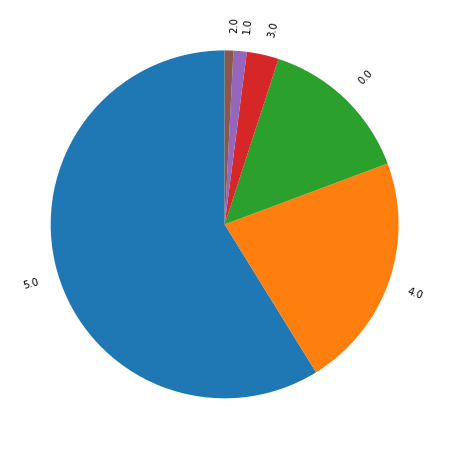

In [76]:
plt.figure(figsize = (8, 8))
plt.pie(driver_score_counts['percentage'],startangle = 90,labels = driver_score_counts['driver_score'],rotatelabels = True)

## Шаг 11

**Сравнила распределение этих оценок с распределением оценок водителей.**

In [80]:
rider_score_counts = (full_taxi.rider_score.value_counts(normalize = True).mul(100)).round (2).reset_index().rename (columns = {'rider_score' : 'percentage', 'index' : 'rider_score'}).sort_values('rider_score')
rider_score_counts

,rider_score,percentage
2,0.0,2.29
4,1.0,0.21
5,2.0,0.19
3,3.0,1.38
1,4.0,8.83
0,5.0,87.10


([<matplotlib.patches.Wedge at 0x7f4adfb42bb0>,
 [Text(-0.07906847244083141, 1.0971545819372372, '0.0'),
  Text(-0.1649064875778295, 1.0875687795972921, '1.0'),
  Text(-0.17855989976903186, 1.0854106882624999, '2.0'),
  Text(-0.23185675928063926, 1.0752871445227457, '3.0'),
  Text(-0.5590529470879916, 0.9473435503302018, '4.0'),
  Text(0.4336889530148115, -1.0108975675274507, '5.0')])

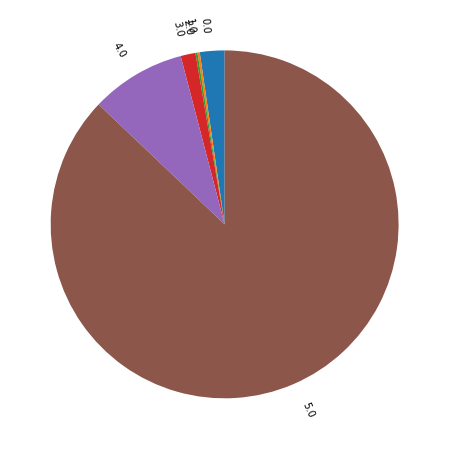

In [82]:
plt.figure(figsize = (8, 8))
plt.pie(rider_score_counts['percentage'],startangle = 90,labels = rider_score_counts['rider_score'],rotatelabels = True)

## Шаг 12

Провела анализ временнЫх данных.

In [86]:
full_taxi[['start_at', 'end_at', 'arrived_at']].head()

,start_at,end_at,arrived_at
0,2010-11-30 03:38:00,2010-11-30 03:39:00,NaN
1,2010-11-28 22:30:00,2010-11-29 00:22:00,2010-11-28 22:02:00
2,2010-11-28 22:30:00,2010-11-28 23:04:00,2010-11-28 22:34:00
3,2010-11-28 01:04:00,2010-11-28 01:32:00,2010-11-28 01:15:00
4,2010-11-28 01:50:00,2010-11-28 02:18:00,2010-11-28 01:43:00


In [89]:
full_taxi[['start_at', 'end_at', 'arrived_at']] = full_taxi[['start_at', 'end_at', 'arrived_at']].apply(pd.to_datetime)
full_taxi.dtypes

journey_id                  object
user_id                     object
driver_id                   object
taxi_id                     object
icon                        object
start_type                  object
start_at            datetime64[ns]
start_lat                   object
start_lon                   object
end_at              datetime64[ns]
end_lat                     object
end_lon                     object
end_state                   object
driver_start_lat            object
driver_start_lon            object
arrived_at          datetime64[ns]
source                      object
driver_score               float64
rider_score                float64
dtype: object

In [92]:
taxi = full_taxi.query("start_type == 'asap' or start_type == 'reserved'")
taxi

,journey_id,user_id,driver_id,taxi_id,icon,start_type,start_at,start_lat,start_lon,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,source,driver_score,rider_score
0,b6206048fbda6d454ead4fa2b4b9beaf,d0de230345480ca6bcc86ce1eb89fbfa,40187316352d2c03ddc19e9c8ad7c514,42aa958edf790ef3d45823386fb734ea,executive,asap,2010-11-30 03:38:00,"-11,95227432","-76,81442261",2010-11-30 03:39:00,"40,4052887","-3,72117424",rider cancel,"-12,08863069","-76,96650439",NaT,iPhone,NaN,NaN
1,d2cf43d9f47c6512b84e1ea7b8746a0c,8e37a68fab5f31a5e2c1b5f77c6bb9e5,1d8ba0bdacccf2d0d70ee9925185d231,1d8ba0bdacccf2d0d70ee99251862c54,executive,reserved,2010-11-28 22:30:00,"-12,0495456","-77,1116799",2010-11-29 00:22:00,"-12,11973","-76,998734",drop off,"-12,04809647","-77,096405",2010-11-28 22:02:00,web,NaN,NaN
2,7c01cd25b39f4f8b234bf56d48a5e9c9,8e37a68fab5f31a5e2c1b5f77c6bb9e5,ecdcce0c956e266ed26c80fd9e5cbb8f,1d3c551d7fc3d0daf73f0a8c82781c2d,executive,reserved,2010-11-28 22:30:00,"-12,0511575","-77,1300437",2010-11-28 23:04:00,"-12,0794453","-77,0896372",drop off,0,0,2010-11-28 22:34:00,web,NaN,NaN
3,ab90a1bf4289d96e78d4a47d7cc2286d,1e639fc120efea2675ac138ebeac4c2f,12c472dd8efc6ed622ae8669251b82f1,c26f22be31323781fd478dbcf8926d44,executive,asap,2010-11-28 01:04:00,"-12,0979889","-77,0223812",2010-11-28 01:32:00,"-12,1192177","-77,0413569",drop off,"-12,08757569","-77,03611258",2010-11-28 01:15:00,web,NaN,4.0
4,d2cf43d9f47c6512b84e1ea7b8740874,2f1882c87731970df63e69d4bc254f96,3abce16ea601affbeae8f50584ce72ef,ab6ee368af1a9e1293acc0d14d1f9338,executive,reserved,2010-11-28 01:50:00,"-12,0903136","-77,0424105",2010-11-28 02:18:00,"43,5398067","-5,6575304",drop off,"-12,11418993","-77,03732522",2010-11-28 01:43:00,Wap,NaN,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11550,b6206048fbda6d454ead4fa2b4948940,86aa09456b63a2a25e0097c55203cb59,ae06c34243f741e203e97c48ebcbd9da,f6254a51b033dcea52c37c715b010474,executive,asap,2010-11-29 13:27:00,"-12,09699249","-77,04226685",2010-11-29 14:08:00,"-12,08663177","-76,99130249",drop off,"-12,09508341","-77,03027931",2010-11-29 13:42:00,iPhone,5.0,5.0
11551,b6206048fbda6d454ead4fa2b4bd2ce5,27bd69801ce062f9b751502b38443d94,3abce16ea601affbeae8f50584ce72ef,ab6ee368af1a9e1293acc0d14d1f9338,executive,asap,2010-11-29 15:29:00,"-12,105472","-77,018854",2010-11-29 15:29:00,"-12,1012259","-77,037736",drop off,0,0,2010-11-29 15:29:00,web,NaN,5.0
11552,cd6fba80de11849ce566009f41dd6dfd,1199f830a03cd75df5e7a7cc7ca8a20c,b66c43e298753a3d39220e53008a4325,b66c43e298753a3d39220e53008a4f19,executive,asap,2010-11-28 22:28:00,"-12,08918381","-76,97341919",2010-11-28 23:22:00,"-12,110672","-77,03985596",drop off,"-12,08397746","-76,96980433",2010-11-28 22:38:00,iPhone,NaN,5.0
11553,d2cf43d9f47c6512b84e1ea7b8754a1d,ae06c34243f741e203e97c48eb62e6db,ecdcce0c956e266ed26c80fd9e5cbb8f,1d3c551d7fc3d0daf73f0a8c82781c2d,executive,asap,2010-11-27 20:11:00,"-12,0988425","-76,9706896",2010-11-27 20:31:00,"-12,15","-77,0166667",drop off,"-12,09828368","-76,97143374",2010-11-27 20:12:00,web,NaN,5.0


## Шаг 13

Проанализировала время подачи машины — долго ли пассажирам приходится ждать такси. 

In [94]:
full_taxi['wait_time'] = full_taxi ['arrived_at'] - full_taxi ['start_at']

In [95]:
full_taxi['wait_time'].median()

Timedelta('0 days 00:05:00')

## Шаг 14

**Определила id водителя, который чаще всего опаздывал на заказы, заранее сделанные клиентами**

In [99]:
timedelta = pd.to_timedelta(0)

In [101]:
full_taxi.query ("start_type == 'reserved' and wait_time > @timedelta")

,journey_id,user_id,driver_id,taxi_id,icon,start_type,start_at,start_lat,start_lon,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,source,driver_score,rider_score,wait_time
2,7c01cd25b39f4f8b234bf56d48a5e9c9,8e37a68fab5f31a5e2c1b5f77c6bb9e5,ecdcce0c956e266ed26c80fd9e5cbb8f,1d3c551d7fc3d0daf73f0a8c82781c2d,executive,reserved,2010-11-28 22:30:00,"-12,0511575","-77,1300437",2010-11-28 23:04:00,"-12,0794453","-77,0896372",drop off,0,0,2010-11-28 22:34:00,web,NaN,NaN,0 days 00:04:00
27,904ecef1a023a13521a66deb52883cd5,ca5f041e0b807120714a6e4616154d37,ae06c34243f741e203e97c48ebcbd9da,f6254a51b033dcea52c37c715b010474,executive,reserved,2010-12-02 22:10:00,"-12,0777187","-76,9661241",2010-12-02 22:32:00,"-12,1053457","-76,9757211",drop off,"-12,0980287","-76,97120964",2010-12-02 22:12:00,web,5.0,5.0,0 days 00:02:00
78,904ecef1a023a13521a66deb52894b37,f78d50ea4f0c83a4a302d9fa8220c654,406921adcca37705ef527b4246bbbff5,ff5c924e0b630fd7c019a423405390be,executive,reserved,2010-12-02 23:15:00,"-12,11600876","-77,03897095",2010-12-02 23:26:00,"-12,11881256","-77,03137207",drop off,"-12,13210005","-77,02336474",2010-12-02 23:16:00,iPhone,NaN,5.0,0 days 00:01:00
114,ae06c34243f741e203e97c48eb42577a,406921adcca37705ef527b4246c12e83,7bf79d646d318c67421797bb50001810,7bf79d646d318c67421797bb5021b2c5,easy,reserved,2010-09-06 22:32:00,"-12,0920039","-77,0433775",2010-09-06 23:23:00,"-12,185865","-77,0219019",drop off,"-12,12865333","-76,99997",2010-09-06 23:10:00,web,NaN,5.0,0 days 00:38:00
116,ae06c34243f741e203e97c48ebcce019,ff5c924e0b630fd7c019a42340594b55,1083bcecf6e3df9df65525ec3a66b5fb,1083bcecf6e3df9df65525ec3a6707c5,easy,reserved,2010-09-09 14:00:00,"-12,0920039","-77,0433775",2010-09-09 14:50:00,"-12,2040443","-77,0079803",drop off,"-12,05650293","-76,94442671",2010-09-09 14:12:00,web,NaN,4.0,0 days 00:12:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11432,0ddb4441be46b643a21e9a52e8d3847d,e4cae9e711f3aa4ce90ed98f2817e733,ecdcce0c956e266ed26c80fd9e1c188c,ecdcce0c956e266ed26c80fd9e7ec7e8,executive,reserved,2010-11-22 23:30:00,"-12,09909821","-77,034729",2010-11-23 00:03:00,"-12,11750031","-77,04302979",rider cancel,"-12,137787","-77,02252999",2010-11-22 23:35:00,iPhone,NaN,NaN,0 days 00:05:00
11469,0ddb4441be46b643a21e9a52e8f1d81a,cf3a94138caddceb3209e4723638ef6f,ec84a73745199ff840ecafcb924383ad,c2ed6bdd0113ad6f195e8586932279ba,executive,reserved,2010-11-22 23:05:00,"-12,09336937","-77,0277499",2010-11-23 00:17:00,"-12,08175521","-76,9089039",drop off,"-12,07526207","-77,09814548",2010-11-22 23:21:00,Android,NaN,5.0,0 days 00:16:00
11472,196d9de717b4c8d6ec0f19c0e82e60a2,10229756e0a48c2a3098e98a4b578f3b,3abce16ea601affbeae8f50584ce72ef,ab6ee368af1a9e1293acc0d14d1f9338,executive,reserved,2010-11-25 14:00:00,"-12,11156198","-77,03950301",2010-11-25 15:01:00,"-12,02778899","-77,10249871",drop off,"-12,1113681","-77,0396595",2010-11-25 14:04:00,Android,5.0,5.0,0 days 00:04:00
11497,dc4a87f8bb95c446781eec6f56e18f6c,8e37a68fab5f31a5e2c1b5f77c6bb9e5,3abce16ea601affbeae8f50584ce72ef,ab6ee368af1a9e1293acc0d14d1f9338,executive,reserved,2010-11-27 03:45:00,"-12,024053","-77,112036",2010-11-27 04:24:00,"-12,092609","-77,047053",drop off,"-12,02108374","-77,10758066",2010-11-27 03:50:00,web,NaN,NaN,0 days 00:05:00


In [103]:
full_taxi.query ("start_type == 'reserved' and wait_time > @timedelta").driver_id.value_counts()

c814db2127582cf95dea1f74f43127c2    1523
d665fb9f75ef5d9cd0fd89479380ba78    1225
ff5c924e0b630fd7c019a4234059fdf4    1111
406921adcca37705ef527b4246c0cfea    1075
ec84a73745199ff840ecafcb924383ad     974
                                    ... 
5c631eab42d9b2426420a89b862a6111       1
5c631eab42d9b2426420a89b862a4a0e       1
29c460e9d44ae084d4631c5ade4ec8a8       1
ef35302138c34b70ddbeb9a52255be1c       1
a8c74399632ec313e9e79e1a30538570       1
Name: driver_id, Length: 168, dtype: int64

In [105]:
full_taxi.query ("start_type == 'reserved' and wait_time > @timedelta").driver_id.value_counts().idxmax()

'406921adcca37705ef527b4246c0cfea'

## Шаг 15

Расширила данные новыми признаками

In [108]:
full_taxi ['month'] = full_taxi.start_at.dt.month

In [109]:
full_taxi ['weekday'] = full_taxi.start_at.dt.day_name()

In [110]:
full_taxi.head()

,journey_id,user_id,driver_id,taxi_id,icon,start_type,start_at,start_lat,start_lon,end_at,...,end_state,driver_start_lat,driver_start_lon,arrived_at,source,driver_score,rider_score,wait_time,month,weekday
0,b6206048fbda6d454ead4fa2b4b9beaf,d0de230345480ca6bcc86ce1eb89fbfa,40187316352d2c03ddc19e9c8ad7c514,42aa958edf790ef3d45823386fb734ea,executive,asap,2010-11-30 03:38:00,"-11,95227432","-76,81442261",2010-11-30 03:39:00,...,rider cancel,"-12,08863069","-76,96650439",NaT,iPhone,NaN,NaN,NaT,11,Tuesday
1,d2cf43d9f47c6512b84e1ea7b8746a0c,8e37a68fab5f31a5e2c1b5f77c6bb9e5,1d8ba0bdacccf2d0d70ee9925185d231,1d8ba0bdacccf2d0d70ee99251862c54,executive,reserved,2010-11-28 22:30:00,"-12,0495456","-77,1116799",2010-11-29 00:22:00,...,drop off,"-12,04809647","-77,096405",2010-11-28 22:02:00,web,NaN,NaN,-1 days +23:32:00,11,Sunday
2,7c01cd25b39f4f8b234bf56d48a5e9c9,8e37a68fab5f31a5e2c1b5f77c6bb9e5,ecdcce0c956e266ed26c80fd9e5cbb8f,1d3c551d7fc3d0daf73f0a8c82781c2d,executive,reserved,2010-11-28 22:30:00,"-12,0511575","-77,1300437",2010-11-28 23:04:00,...,drop off,0,0,2010-11-28 22:34:00,web,NaN,NaN,0 days 00:04:00,11,Sunday
3,ab90a1bf4289d96e78d4a47d7cc2286d,1e639fc120efea2675ac138ebeac4c2f,12c472dd8efc6ed622ae8669251b82f1,c26f22be31323781fd478dbcf8926d44,executive,asap,2010-11-28 01:04:00,"-12,0979889","-77,0223812",2010-11-28 01:32:00,...,drop off,"-12,08757569","-77,03611258",2010-11-28 01:15:00,web,NaN,4.0,0 days 00:11:00,11,Sunday
4,d2cf43d9f47c6512b84e1ea7b8740874,2f1882c87731970df63e69d4bc254f96,3abce16ea601affbeae8f50584ce72ef,ab6ee368af1a9e1293acc0d14d1f9338,executive,reserved,2010-11-28 01:50:00,"-12,0903136","-77,0424105",2010-11-28 02:18:00,...,drop off,"-12,11418993","-77,03732522",2010-11-28 01:43:00,Wap,NaN,5.0,-1 days +23:53:00,11,Sunday


## Шаг 16

**Построила график количества заказов по месяцам и определите месяц с наименьшим количеством заказов летом.**

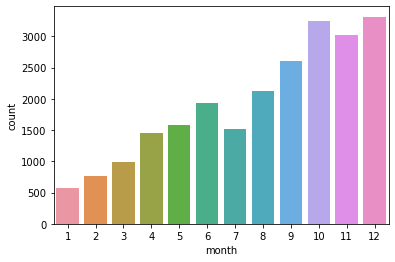

In [111]:
sns.countplot(data = full_taxi, x = 'month')

## Шаг 17

**Определила, в какой день недели поступает меньше всего заказов.**

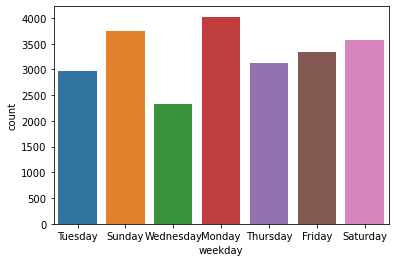

In [112]:
sns.countplot(data = full_taxi, x = 'weekday')

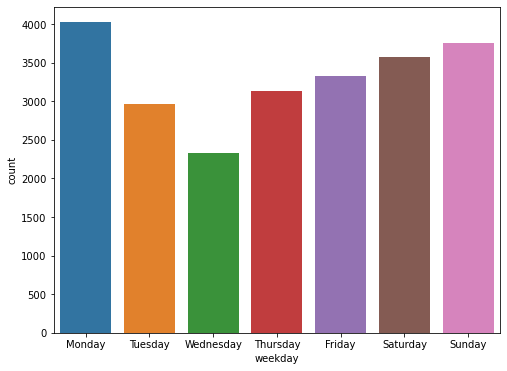

In [116]:
plt.figure(figsize=(8,6)) 
sns.countplot(data = full_taxi, x = 'weekday', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

## Шаг 18

**Посчитала метрику MAU, постройла её график**  

In [119]:
unique_user = full_taxi.groupby('month').nunique('user_id')
unique_user

,journey_id,user_id,driver_id,taxi_id,icon,start_type,start_at,start_lat,start_lon,end_at,...,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,source,driver_score,rider_score,wait_time,weekday
month,,,,,,,,,,,,,,,,,,,,,
1,575,102,40,42,2,3,566,490,463,554,...,494,5,513,514,450,5,4,5,64,7
2,770,111,44,45,2,3,741,633,570,746,...,624,6,653,653,581,5,6,6,63,7
3,986,163,48,49,2,3,939,685,660,961,...,727,5,841,841,751,5,6,6,81,7
4,1448,254,51,53,2,3,1359,958,908,1387,...,985,6,1181,1179,1014,5,6,5,83,7
5,1585,275,56,58,2,3,1478,1110,1034,1525,...,1113,5,1305,1301,1119,5,6,6,78,7
6,1939,309,55,71,2,3,1752,1241,1120,1833,...,1240,6,1602,1611,1404,5,6,6,83,7
7,1516,318,57,71,2,3,1433,1077,993,1454,...,1042,6,1316,1314,1182,5,6,6,80,7
8,2120,377,71,88,3,2,1920,1507,1376,1999,...,1395,6,1761,1755,1567,5,6,5,84,7
9,2598,416,63,77,3,2,2313,1587,1400,2400,...,1450,5,2093,2083,1897,5,6,6,88,7


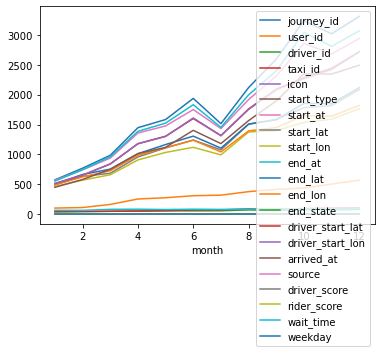

In [120]:
unique_user.plot.line()

## Итоги

В этом проекте я собрала воедино и проанализировала данные о поездках на такси в Перу в разрезе по платформам, построила графики и сравнила оценки водителей и пассажиров, определила самого опаздывающего водителя и причины его опозданий, посмотрела на годовую и недельную сезонность заказов, проанализировала метрику MAU.